In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

import mlflow
from sklearn.metrics import classification_report, roc_auc_score



In [2]:
df = pd.read_csv('data/Loan_Data.csv')

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


Aucune donnée nulle dans la df, et toutes les colonnes ont le même nombre de lignes. 

In [5]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [6]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

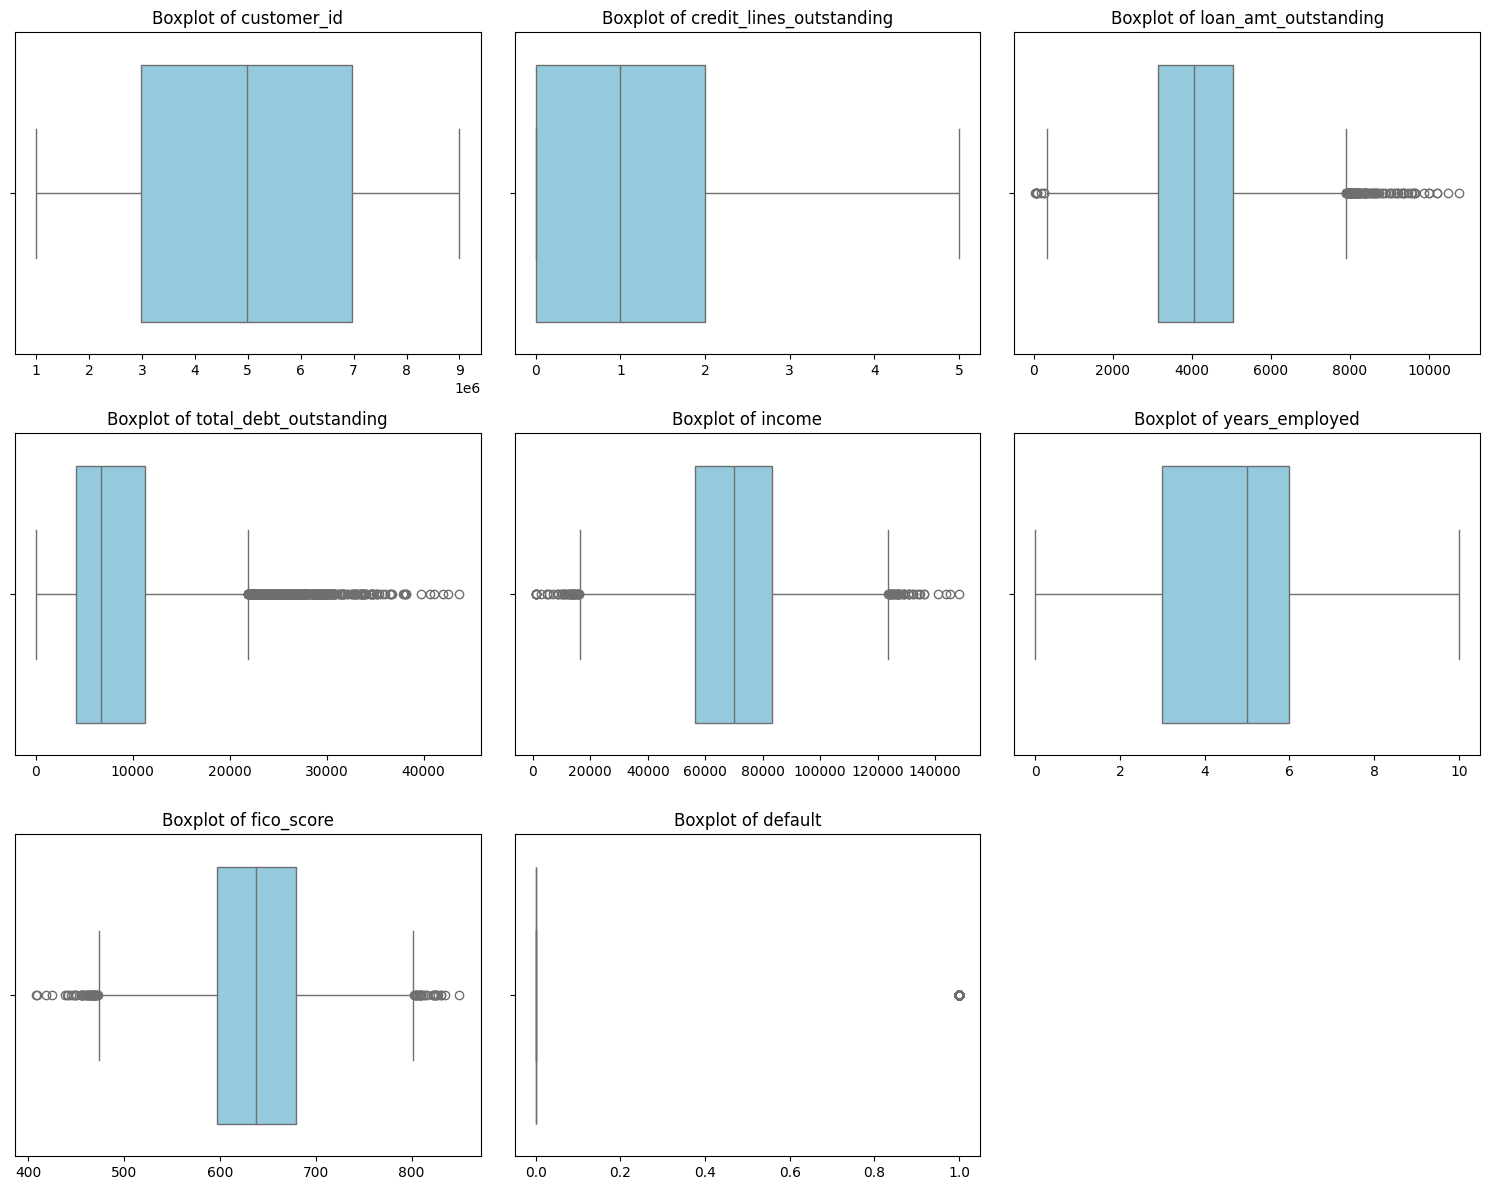

In [7]:
# 1. Sélection des colonnes numériques
numerical_features = df.select_dtypes(include=['number']).columns
n_features = len(numerical_features)

# 2. Configuration de la grille (ex: 3 colonnes)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# 3. Création de la figure unique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # On aplatit le tableau d'axes pour boucler facilement

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('') # Optionnel : retire le label x pour plus de clarté

# 4. Supprimer les axes vides si le nombre de features n'est pas un multiple de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Default : colonne de prédiction. Indique si client a fait défaut ou non sur son prêt. 

Logs because data is skewed. 

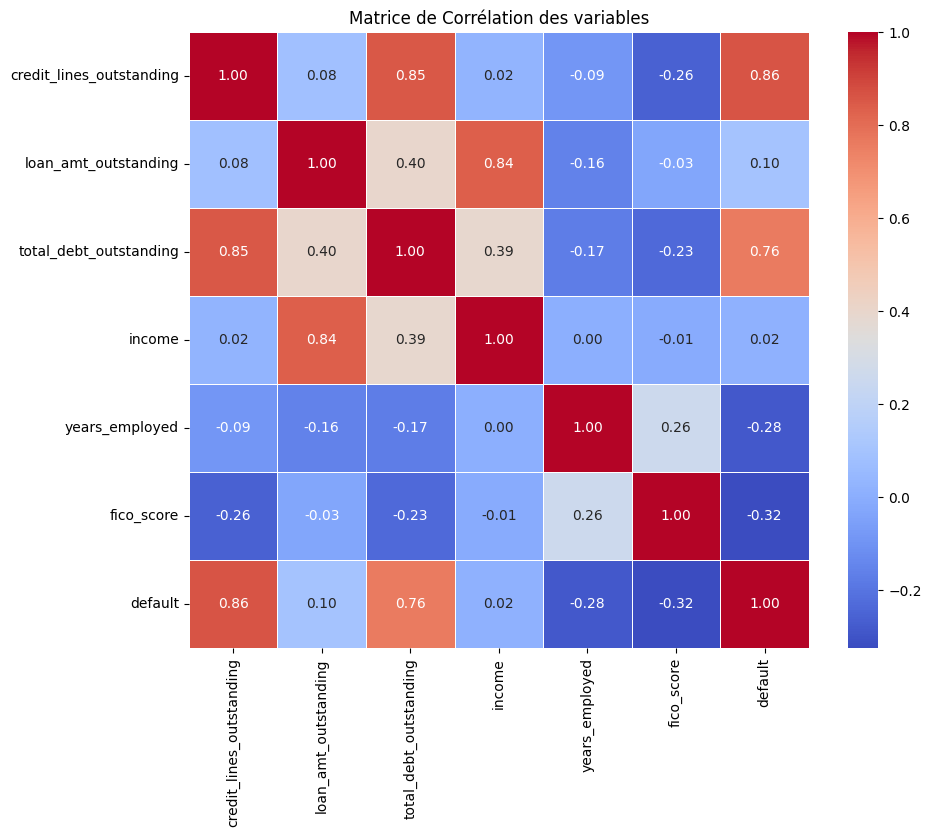

In [8]:
corr_matrix = df.drop(columns=['customer_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables")
plt.show()

In [9]:
print(df.corr()["default"].sort_values(ascending=False))

default                     1.000000
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
loan_amt_outstanding        0.098978
income                      0.016309
customer_id                 0.006927
years_employed             -0.284506
fico_score                 -0.324515
Name: default, dtype: float64


data leakage from credit_lines_outstanding

# Choix des variables et division train/test

In [10]:
#partie intégrée à la pipeline feature engineering
'''cols_to_log = ['total_debt_outstanding', 'loan_amt_outstanding']
for col in cols_to_log:
    df[col] = np.log1p(df[col])'''

"cols_to_log = ['total_debt_outstanding', 'loan_amt_outstanding']\nfor col in cols_to_log:\n    df[col] = np.log1p(df[col])"

In [11]:
X_raw = df.drop(columns=['default', 'customer_id', "credit_lines_outstanding"])
y = df['default']

In [16]:
def feature_engineering(X):
    X = X.copy()
    X["dti"] = np.log(X["total_debt_outstanding"]) / X["income"]
    X["lti"] = np.log(X["loan_amt_outstanding"])   / X["income"]
    return X[["income", "years_employed", "fico_score", "dti", "lti"]]

preprocessor = Pipeline([
    ("features", FunctionTransformer(feature_engineering))
])

# Fit sur X_raw (obligatoire même si FunctionTransformer n'apprend rien)
X = preprocessor.fit_transform(X_raw)
print(X)

           income  years_employed  fico_score       dti       lti
0     78039.38546               5         605  0.000106  0.000110
1     26648.43525               2         572  0.000338  0.000284
2     65866.71246               4         602  0.000116  0.000123
3     74356.88347               5         612  0.000105  0.000114
4     23448.32631               6         631  0.000319  0.000307
...           ...             ...         ...       ...       ...
9995  42691.62787               5         697  0.000184  0.000188
9996  79969.50521               8         615  0.000108  0.000104
9997  38192.67591               5         596  0.000222  0.000210
9998  50929.37206               2         647  0.000136  0.000159
9999  30611.62821               6         757  0.000262  0.000247

[10000 rows x 5 columns]


In [13]:
#Feature engineering
'''df["dti"] = df["total_debt_outstanding"] / df["income"]
df["lti"] = df["loan_amt_outstanding"]   / df["income"]

X = df[["income", "years_employed", "fico_score", "dti", "lti"]]'''

'df["dti"] = df["total_debt_outstanding"] / df["income"]\ndf["lti"] = df["loan_amt_outstanding"]   / df["income"]\n\nX = df[["income", "years_employed", "fico_score", "dti", "lti"]]'

In [14]:
#y = df['default']

#X = df.drop(columns=['default', 'customer_id', "credit_lines_outstanding"])

# Vérification rapide
#print(f"Used features : {X.columns.tolist()}")

In [17]:
#Ajout de stratify pour compenser the class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
print(y_train.value_counts(normalize=True))

default
0    0.814875
1    0.185125
Name: proportion, dtype: float64


In [20]:
#Scaler pour regression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Définition et entraînement des modèles

## Définition des modèles

In [21]:
## Models definition 
from xgboost import XGBClassifier

#--- Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

#--- Decision Tree
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5], # None = l'arbre pousse jusqu'au bout - overfitting
    'min_samples_split': [20, 50],
    'min_samples_leaf': [20, 50],
    'class_weight': ['balanced']
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc', # roc_auc pour dataset déséquilibré
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

#--- Random Forest
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [3, 5],          # Profondeur de chaque arbre
    'min_samples_leaf': [20, 50],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False],
    'class_weight': ['balanced']            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_


#XGBoost 
#TODO : XGB à approfondir, juste un exemple
xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    colsample_bytree=0.8,
    scale_pos_weight=4.40,
    random_state=42,
    eval_metric='auc'
)

xgb.fit(X_train, y_train)

c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Entraînement des modèles

In [22]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("credit-loan-prediction")

<Experiment: artifact_location='file:///c:/Users/alize/Documents/SDA_2025_2026/projet_mlops/creditloanprediction/mlruns/1', creation_time=1774797922153, experiment_id='1', last_update_time=1774797922153, lifecycle_stage='active', name='credit-loan-prediction', tags={}, workspace='default'>

In [23]:
# Engistrement de la pipeline de transformation de données

with mlflow.start_run(run_name="preprocessor"):
    mlflow.sklearn.log_model(
        preprocessor,
        name="preprocessor",
        registered_model_name="credit_loan_preprocessor"
    )
    print("Preprocessor enregistré.")

2026/04/06 13:28:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 13:28:50 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Preprocessor enregistré.


Successfully registered model 'credit_loan_preprocessor'.
Created version '1' of model 'credit_loan_preprocessor'.


In [24]:
# Engistrement des modèles dans mlflow pour comparaison

models = {
    "LogisticRegression": lr,
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "XGB":xgb
}


for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        
        X_eval = X_test_scaled if model_name == "LogisticRegression" else X_test

        y_pred = model.predict(X_eval)
        probas = model.predict_proba(X_eval)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        mlflow.log_metric("accuracy",        report["accuracy"])
        mlflow.log_metric("f1_class_1",      report["1"]["f1-score"])
        mlflow.log_metric("recall_class_1",  report["1"]["recall"])
        mlflow.log_metric("precision_class_1", report["1"]["precision"])
        mlflow.log_metric("roc_auc",         roc_auc_score(y_test, probas))

        model_info = mlflow.sklearn.log_model(
            model, 
            name=model_name,
            registered_model_name=model_name
        )

        # Staging
        client = mlflow.tracking.MlflowClient()
        latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
        client.transition_model_version_stage(
            name=model_name,
            version=latest_version,
            stage="Staging"
        )
        print(f"Modèle '{model_name}' v{latest_version} → Staging")


2026/04/06 13:29:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'LogisticRegression'.
Created version '1' of model 'LogisticRegression'.
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\a

Modèle 'LogisticRegression' v1 → Staging


Successfully registered model 'DecisionTree'.
Created version '1' of model 'DecisionTree'.
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.tra

Modèle 'DecisionTree' v1 → Staging


2026/04/06 13:29:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RandomForest'.
Created version '1' of model 'RandomForest'.
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\alize\AppData

Modèle 'RandomForest' v1 → Staging


2026/04/06 13:29:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle 'XGB' v1 → Staging


Successfully registered model 'XGB'.
Created version '1' of model 'XGB'.
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\1545787789.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_vers

## Enregistrement du meilleur modèle

In [25]:
import time

# Trouver le meilleur run basé sur roc_auc
runs = mlflow.search_runs(
    experiment_names=["credit-loan-prediction"],
    order_by=["start_time DESC"]
)

# Garder les 4 derniers puis trier par roc_auc
best_run = runs.head(4).sort_values("metrics.roc_auc", ascending=False).iloc[0]

print(f"Meilleur modèle : {best_run['tags.mlflow.runName']}")
print(f"F1 score : {best_run['metrics.f1_class_1']:.4f}")
print(f"Accuracy : {best_run['metrics.accuracy']:.4f}")

# Enregistrer le meilleur modèle dans le Model Registry
best_run_id = best_run["run_id"]
model_name = best_run["tags.mlflow.runName"]

mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/{model_name}",
    name="best_credit_loan_model"
)

# Laisser le temps au registry d'enregistrer
time.sleep(2)

client = mlflow.tracking.MlflowClient()

latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version

# Passer en Production
client.transition_model_version_stage(
    name="best_credit_loan_model",
    version=latest_version,
    stage="Production"
)


print(f"Meilleur modèle '{model_name}' passé en production.")

Registered model 'best_credit_loan_model' already exists. Creating a new version of this model...
2026/04/06 13:29:32 WARNING mlflow.tracking._model_registry.fluent: Run with id bfb31c32cead46b78e28d3370ee4a439 has no artifacts at artifact path 'XGB', registering model based on models:/m-26f8edd5b57949e389ea6c5aeb065a97 instead


Meilleur modèle : XGB
F1 score : 0.8800
Accuracy : 0.9520


Created version '12' of model 'best_credit_loan_model'.


Meilleur modèle 'XGB' passé en production.


C:\Users\alize\AppData\Local\Temp\ipykernel_10348\359894899.py:30: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_10348\359894899.py:33: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


### Vérification des probabilités de chaque modèle

In [ ]:
model = lr
probas = model.predict_proba(X_test_scaled)[:, 1]
print(probas[:20])

[0.09812685 0.10910943 0.45842654 0.30365036 0.43904231 0.26777972
 0.35052837 0.72141356 0.06248977 0.57900285 0.70317134 0.07633785
 0.44550559 0.29039173 0.23270635 0.63457463 0.53286038 0.48757269
 0.54273853 0.20870832]


In [ ]:
model = best_dt
probas = model.predict_proba(X_test)[:, 1]
print(probas[:20])

[0.33086661 0.33086661 0.64714992 0.04951258 0.60639443 0.33086661
 0.33086661 0.82785752 0.33086661 0.68025735 0.21575376 0.33086661
 0.         0.33086661 0.06342427 0.82785752 0.60639443 0.06342427
 0.60639443 0.11583032]


In [ ]:
print(grid_search_rf.best_params_)
print("Train:", grid_search_rf.score(X_train, y_train))
print("Test: ", grid_search_rf.score(X_test, y_test))

{'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 100}
Train: 0.910617994106253
Test:  0.8954418836013929


In [ ]:
model = xgb
probas = model.predict_proba(X_test)[:, 1]
print(probas[:100])

[2.2304719e-03 4.4191297e-02 6.7502059e-02 7.8439051e-03 7.0213564e-02
 3.7075266e-01 3.0739734e-02 9.6526861e-01 3.6472206e-03 1.8319415e-02
 2.4805317e-02 1.6558278e-02 1.3318529e-02 3.6210760e-02 7.3441402e-03
 9.3514053e-03 6.2731189e-01 1.6632386e-02 8.0867574e-02 1.6256537e-02
 2.4393244e-02 3.3705309e-02 5.8143999e-02 8.3435202e-01 7.1324867e-01
 9.5974147e-01 9.9180518e-03 8.8448627e-03 5.0343957e-02 2.1930158e-03
 1.1653486e-01 8.8591605e-01 8.4932381e-03 3.6863573e-02 8.6518504e-02
 9.5036882e-01 2.7411453e-02 4.0013912e-01 9.6959698e-01 8.9076769e-01
 3.9745262e-01 1.1689439e-02 2.7978972e-01 9.7251636e-01 1.0339827e-02
 4.9030542e-02 2.1348788e-01 6.7060226e-01 2.4559068e-02 1.7815592e-02
 1.1023795e-01 5.1978701e-03 2.6856153e-03 2.8486711e-01 1.1433791e-02
 8.0873976e-03 1.3264984e-02 2.1852002e-02 5.2641421e-03 2.6393506e-01
 8.6045408e-01 1.0639603e-02 4.5583744e-02 3.7069738e-02 9.7401878e-03
 6.6689022e-02 6.1714355e-02 5.4492038e-02 4.3094996e-01 8.9478570e-01
 2.047

### Feature importance 
#TODO : améliorer cette partie

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(grid_search_rf.best_estimator_, X_test, y_test, n_repeats=10)
for i, col in enumerate(X.columns):
    print(f"{col}: {result.importances_mean[i]:.4f}")

income: 0.1104
years_employed: 0.0284
fico_score: 0.0312
dti: 0.1902
lti: 0.0155


# Archive : étude de chaque modèle séparé
#TODO : à réintégrer ou supprimer

**1 - Logistic Regression**

In [ ]:
#Training Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)


print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1630
           1       0.91      0.65      0.76       370

    accuracy                           0.92      2000
   macro avg       0.92      0.82      0.85      2000
weighted avg       0.92      0.92      0.92      2000



In [ ]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

# Évaluation
y_pred = lr.predict(X_test_scaled)
probas = lr.predict_proba(X_test_scaled)[:, 1]
print(probas[:20])
print(classification_report(y_test, y_pred))

[0.09812685 0.10910943 0.45842654 0.30365036 0.43904231 0.26777972
 0.35052837 0.72141356 0.06248977 0.57900285 0.70317134 0.07633785
 0.44550559 0.29039173 0.23270635 0.63457463 0.53286038 0.48757269
 0.54273853 0.20870832]
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1630
           1       0.39      0.73      0.51       370

    accuracy                           0.74      2000
   macro avg       0.66      0.73      0.66      2000
weighted avg       0.82      0.74      0.76      2000



c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
print(importance.sort_values(by='Coefficient', ascending=False))

          Feature  Coefficient
3             dti    18.831770
0          income    -0.159970
2      fico_score    -0.624975
1  years_employed    -0.734765
4             lti   -20.683406


# Decision Tree

In [ ]:
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None], # None = l'arbre pousse jusqu'au bout
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1', # On optimise le F1-score car le défaut est une classe sensible
    n_jobs=-1
)

# 3. Entraînement
grid_search_dt.fit(X_train, y_train)

# 4. Affichage des meilleurs paramètres
print("Meilleurs paramètres Arbre :", grid_search_dt.best_params_)

# 5. Évaluation du meilleur modèle
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\nReport de l'Arbre Optimisé :")
print(classification_report(y_test, y_pred_best_dt))

Meilleurs paramètres Arbre : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Report de l'Arbre Optimisé :
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1630
           1       0.85      0.83      0.84       370

    accuracy                           0.94      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.94      0.94      0.94      2000



# Random Forest

In [ ]:
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [10, 20, None],          # Profondeur de chaque arbre
    'min_samples_leaf': [1, 2, 4],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False]            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Entraînement
grid_search_rf.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres Random Forest :", grid_search_rf.best_params_)

# 5. Évaluation finale
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nReport du Random Forest Optimisé :")
print(classification_report(y_test, y_pred_rf))

KeyboardInterrupt: 

In [ ]:
# Récupérer l'importance des variables du Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
log_importances = pd.Series(abs(log_reg.coef_[0]), index=X.columns).sort_values(ascending=False)

print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)

TOP FEATURES - Random Forest:
 dti               0.347517
income            0.238267
fico_score        0.167602
lti               0.166494
years_employed    0.080120
dtype: float64

TOP FEATURES - LogReg:
 lti               20.683406
dti               18.831770
years_employed     0.734765
fico_score         0.624975
income             0.159970
dtype: float64


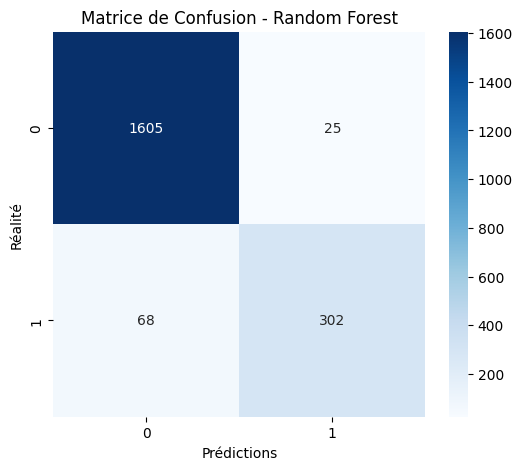

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

In [ ]:
# Save the Random Forest model
os.makedirs('models', exist_ok=True)  
joblib.dump(best_rf, 'models/credit_risk_model_rf.pkl')

# Save the scaler (in case you need it for LogReg later)
joblib.dump(scaler, 'models/scaler_credit.pkl')

print("Models saved successfully!")

Models saved successfully!
